# Benchmark Model Training

### Logistic Regression, Random Forest, XGBoost


## Logistic Regression (Mean Rating)


In [1]:
import sys
from pathlib import Path

# Add project root to path
sys.path.append(str(Path("..").resolve()))


from helpers import ModelData
from constants import PROCESSED_DATA_FOLDER
import numpy as np

model_data = ModelData.from_pickle(PROCESSED_DATA_FOLDER / "processed_data.pkl")
model_data

/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModelData(n_total=921, n_train=500, n_obs=64887)

In [2]:
# Random Seed für Reproduzierbarkeit
SEED = 42

In [3]:
# Aufteilung in business_covariates und rating_stats

# Business covariates (ohne Rating-Statistiken und OHNE Closed!)
business_features = [
    "density",
    "Checkin",
    "category",
    "chain",
    "Price.Level",
    "Restaurant.Size",
    "Number.of.Seats",
    "ZRI",
    "Distance.To.City.Centre",
    "Age",
]

# Rating statistics
rating_features = [
    "VAR",
    "MEAN",
    "ENTR",
    "COUNT",
    "ONE_STAR",
    "TWO_STAR",
    "THREE_STAR",
    "FOUR_STAR",
    "FIVE_STAR",
    "l_COUNT",
]

print(f"Business features: {len(business_features)} Variablen")
print(f"Rating features: {len(rating_features)} Variablen")
print(f"Gesamt: {len(business_features) + len(rating_features)} Variablen")

# Train/Test Split basierend auf train_indices
train_indices = model_data.train_indices
test_indices = np.array(
    [i for i in range(len(model_data.benchmark_covariates)) if i not in train_indices]
)
eval_indices = model_data.eval_indices
calibration_indices = model_data.calibration_indices

print(f"\nTrain/Test Split:")
print(f"  Training samples: {len(train_indices)}")
print(f"  Test samples: {len(eval_indices)}")
print(f"  Calibration samples: {len(calibration_indices)}")
print(f"  Total: {len(train_indices) + len(eval_indices) + len(calibration_indices)}")

Business features: 10 Variablen
Rating features: 10 Variablen
Gesamt: 20 Variablen

Train/Test Split:
  Training samples: 500
  Test samples: 321
  Calibration samples: 100
  Total: 921


## Datenvorbereitungen für alle Modelle


In [4]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Target Variable vorbereiten
y = model_data.benchmark_covariates["Closed"].map({"Open": 0, "Closed": 1}).values

# ============================================================================
# 1. X_mean: Nur Mean Rating
# ============================================================================
X_mean = model_data.benchmark_covariates[["MEAN"]].values

# ============================================================================
# 2. X_business: Business Covariates (mit Preprocessing)
# ============================================================================
df_business = model_data.benchmark_covariates[business_features].copy()

# Kategorische Variablen identifizieren
categorical_cols = ["category"]
numeric_cols = [col for col in business_features if col not in categorical_cols]

# One-Hot Encoding
df_business_encoded = pd.get_dummies(
    df_business, columns=categorical_cols, drop_first=True
)

# Imputation und Standardisierung (nur auf Train-Daten fitten!)
imputer_business = SimpleImputer(strategy="median")
scaler_business = StandardScaler()

# Train-Daten preprocessing
numeric_train = df_business_encoded.iloc[train_indices][numeric_cols]
imputer_business.fit(numeric_train)
scaler_business.fit(imputer_business.transform(numeric_train))

# Transform für alle Daten
numeric_data_imputed = imputer_business.transform(df_business_encoded[numeric_cols])
numeric_data = scaler_business.transform(numeric_data_imputed)

# Kombiniere Features
X_business = pd.DataFrame(
    numeric_data, columns=numeric_cols, index=df_business_encoded.index
)
dummy_cols = [col for col in df_business_encoded.columns if col not in numeric_cols]
X_business = pd.concat([X_business, df_business_encoded[dummy_cols]], axis=1)

# ============================================================================
# 3. X_all: Alle Variablen (Business Covariates + Rating Stats)
# ============================================================================
all_features = business_features + rating_features

# Daten vorbereiten
df_all = model_data.benchmark_covariates[all_features].copy()

# Kategorische Variablen
categorical_cols = ["category"]
numeric_cols = [col for col in all_features if col not in categorical_cols]

# One-Hot Encoding
df_all_encoded = pd.get_dummies(df_all, columns=categorical_cols, drop_first=True)

# Imputation und Standardisierung (nur auf Train-Daten fitten!)
imputer_all = SimpleImputer(strategy="median")
scaler_all = StandardScaler()

# Train-Daten preprocessing
numeric_train = df_all_encoded.iloc[train_indices][numeric_cols]
imputer_all.fit(numeric_train)
scaler_all.fit(imputer_all.transform(numeric_train))

# Transform für alle Daten
numeric_data_imputed = imputer_all.transform(df_all_encoded[numeric_cols])
numeric_data = scaler_all.transform(numeric_data_imputed)

# Kombiniere Features
X_all = pd.DataFrame(numeric_data, columns=numeric_cols, index=df_all_encoded.index)
dummy_cols = [col for col in df_all_encoded.columns if col not in numeric_cols]
X_all = pd.concat([X_all, df_all_encoded[dummy_cols]], axis=1)

# ============================================================================
# Train/Test Split für alle Feature-Sets
# ============================================================================
X_mean_train, X_mean_test = X_mean[train_indices], X_mean[test_indices]
X_business_train = X_business.iloc[train_indices]
X_business_test = X_business.iloc[test_indices]
X_all_train = X_all.iloc[train_indices]
X_all_test = X_all.iloc[test_indices]

y_train, y_test = y[train_indices], y[test_indices]

# ============================================================================
# Zusammenfassung
# ============================================================================
print()
print("DATENVORBEREITUNGEN ABGESCHLOSSEN")
print("=" * 80)
print(f"\nTarget Variable (y):")
print(
    f"  Train samples: {len(y_train)} (Closed: {sum(y_train)}, Open: {len(y_train) - sum(y_train)})"
)
print(
    f"  Test samples:  {len(y_test)} (Closed: {sum(y_test)}, Open: {len(y_test) - sum(y_test)})"
)

print(f"\nFeature Sets:")
print(
    f"  X_mean shape:     {X_mean.shape} (Train: {X_mean_train.shape}, Test: {X_mean_test.shape})"
)
print(
    f"  X_business shape: {X_business.shape} (Train: {X_business_train.shape}, Test: {X_business_test.shape})"
)
print(
    f"  X_all shape:      {X_all.shape} (Train: {X_all_train.shape}, Test: {X_all_test.shape})"
)

print(f"\nFeature Details:")
print(f"  Mean Rating: 1 Variable")
print(
    f"  Business Covariates: {len(X_business.columns)} Variablen (nach One-Hot Encoding)"
)
print(f"  All Features: {len(X_all.columns)} Variablen (nach One-Hot Encoding)")


DATENVORBEREITUNGEN ABGESCHLOSSEN

Target Variable (y):
  Train samples: 500 (Closed: 127, Open: 373)
  Test samples:  421 (Closed: 98, Open: 323)

Feature Sets:
  X_mean shape:     (921, 1) (Train: (500, 1), Test: (421, 1))
  X_business shape: (921, 17) (Train: (500, 17), Test: (421, 17))
  X_all shape:      (921, 27) (Train: (500, 27), Test: (421, 27))

Feature Details:
  Mean Rating: 1 Variable
  Business Covariates: 17 Variablen (nach One-Hot Encoding)
  All Features: 27 Variablen (nach One-Hot Encoding)


## Model 1: Logistic Regression mit Mean Rating


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from helpers import get_model_performance, print_model_summary

# Train Logistic Regression
lr_mean = LogisticRegression(random_state=SEED, max_iter=1000)
lr_mean.fit(X_mean_train, y_train)

# Predictions auf alle Daten (inkl. Calibration und Eval)
y_proba_mean_all = lr_mean.predict_proba(X_mean)[:, 1]
y_proba_mean_train = lr_mean.predict_proba(X_mean_train)[:, 1]
y_proba_mean_test = lr_mean.predict_proba(X_mean_test)[:, 1]

# Evaluation mit print_model_summary
print_model_summary(
    "MODEL 1: Logistic Regression - Mean Rating",
    y_train,
    y_proba_mean_train,
    y_test,
    y_proba_mean_test,
)

# Performance Metrics mit get_model_performance
perf_lr_mean = get_model_performance(
    y_prob=y_proba_mean_all,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)
print("\nDetailed Performance Metrics (Calibration + Eval):")
print(perf_lr_mean)

# Koeffizienten
print(f"\nKoeffizient MEAN: {lr_mean.coef_[0][0]:.4f}")
print(f"Intercept: {lr_mean.intercept_[0]:.4f}")

MODEL 1: Logistic Regression - Mean Rating

TRAIN Performance:
  ROC-AUC: 0.4837

TEST Performance:
  ROC-AUC: 0.5239

Detailed Performance Metrics (Calibration + Eval):
{'auc': 48.77, 'balanced_accuracy': np.float64(46.92), 'f1': np.float64(26.09), 'specificity': np.float64(56.85), 'sensitivity': np.float64(36.99), 'threshold': np.float64(0.2573)}

Koeffizient MEAN: 0.0492
Intercept: -1.2525


## Model 2: Logistic Regression mit Business Covariates


In [6]:
# Train Logistic Regression
lr_business = LogisticRegression(random_state=SEED, max_iter=1000)
lr_business.fit(X_business_train, y_train)

# Predictions
y_proba_business_all = lr_business.predict_proba(X_business)[:, 1]
y_proba_business_train = lr_business.predict_proba(X_business_train)[:, 1]
y_proba_business_test = lr_business.predict_proba(X_business_test)[:, 1]

# Evaluation mit print_model_summary
print_model_summary(
    "MODEL 2: Logistic Regression - Business Covariates",
    y_train,
    y_proba_business_train,
    y_test,
    y_proba_business_test,
)

# Performance Metrics mit get_model_performance
perf_lr_business = get_model_performance(
    y_prob=y_proba_business_all,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)
print("\nDetailed Performance Metrics (Calibration + Eval):")
print(perf_lr_business)

# Top 10 wichtigste Features
coef_df = pd.DataFrame(
    {"feature": X_business.columns, "coefficient": lr_business.coef_[0]}
)
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("\nTop 10 wichtigste Features:")
print(coef_df.head(10)[["feature", "coefficient"]])

MODEL 2: Logistic Regression - Business Covariates

TRAIN Performance:
  ROC-AUC: 0.7989

TEST Performance:
  ROC-AUC: 0.7011

Detailed Performance Metrics (Calibration + Eval):
{'auc': 70.45, 'balanced_accuracy': np.float64(64.08), 'f1': np.float64(44.9), 'specificity': np.float64(52.82), 'sensitivity': np.float64(75.34), 'threshold': np.float64(0.2085)}

Top 10 wichtigste Features:
               feature  coefficient
11  category_Fast Food    -1.151718
2                chain    -1.015150
10      category_Cafes    -0.815328
12    category_Mexican    -0.610443
8                  Age    -0.478094
1              Checkin    -0.399984
13      category_Other     0.350728
14      category_Pizza     0.269611
0              density     0.238935
6                  ZRI     0.168032


## Model 3: Logistic Regression mit allen Variablen (Business + Rating Stats)


In [7]:
# Train Logistic Regression
lr_all = LogisticRegression(random_state=SEED, max_iter=1000)
lr_all.fit(X_all_train, y_train)

# Predictions
y_proba_all_all = lr_all.predict_proba(X_all)[:, 1]
y_proba_all_train = lr_all.predict_proba(X_all_train)[:, 1]
y_proba_all_test = lr_all.predict_proba(X_all_test)[:, 1]

# Evaluation mit print_model_summary
print_model_summary(
    "MODEL 3: Logistic Regression - All Features",
    y_train,
    y_proba_all_train,
    y_test,
    y_proba_all_test,
)

# Performance Metrics mit get_model_performance
perf_lr_all = get_model_performance(
    y_prob=y_proba_all_all,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)
print("\nDetailed Performance Metrics (Calibration + Eval):")
print(perf_lr_all)

# Top 10 wichtigste Features
coef_df_all = pd.DataFrame({"feature": X_all.columns, "coefficient": lr_all.coef_[0]})
coef_df_all["abs_coefficient"] = coef_df_all["coefficient"].abs()
coef_df_all = coef_df_all.sort_values("abs_coefficient", ascending=False)

print("\nTop 10 wichtigste Features:")
print(coef_df_all.head(10)[["feature", "coefficient"]])

MODEL 3: Logistic Regression - All Features

TRAIN Performance:
  ROC-AUC: 0.8541

TEST Performance:
  ROC-AUC: 0.7963

Detailed Performance Metrics (Calibration + Eval):
{'auc': 80.11, 'balanced_accuracy': np.float64(71.79), 'f1': np.float64(53.54), 'specificity': np.float64(70.97), 'sensitivity': np.float64(72.6), 'threshold': np.float64(0.2075)}

Top 10 wichtigste Features:
                     feature  coefficient
21        category_Fast Food    -1.314882
2                      chain    -1.022622
8                        Age    -0.710697
16                 FOUR_STAR     0.670784
26  category_Speciality Food     0.650959
20            category_Cafes    -0.626522
22          category_Mexican    -0.477659
24            category_Pizza     0.470484
25            category_Salad     0.390828
17                 FIVE_STAR    -0.306440


## Vergleich der drei Benchmark-Modelle


VERGLEICH DER BENCHMARK-MODELLE
              Model          Features  Train ROC-AUC  Test ROC-AUC
        Mean Rating MEAN (1 Variable)       0.483745      0.523883
Business Covariates      17 Variablen       0.798907      0.701144
       All Features      27 Variablen       0.854130      0.796266


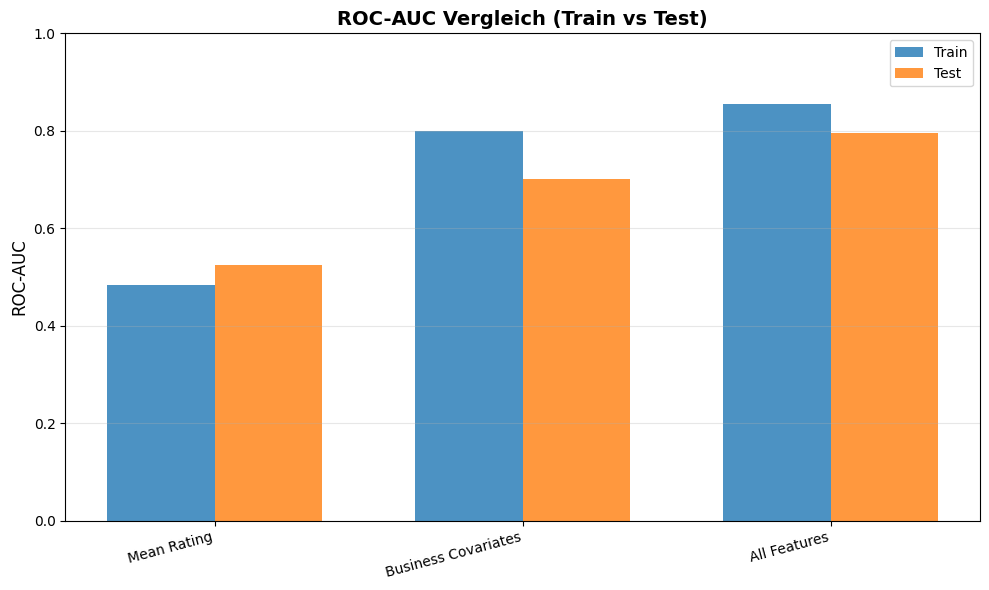


Bestes Modell (Test ROC-AUC): All Features
Test ROC-AUC: 0.7963


In [8]:
# Vergleichstabelle erstellen (TEST Performance!)
import pandas as pd

results_comparison = pd.DataFrame(
    {
        "Model": ["Mean Rating", "Business Covariates", "All Features"],
        "Features": [
            "MEAN (1 Variable)",
            f"{len(X_business.columns)} Variablen",
            f"{len(X_all.columns)} Variablen",
        ],
        "Train ROC-AUC": [
            roc_auc_score(y_train, y_proba_mean_train),
            roc_auc_score(y_train, y_proba_business_train),
            roc_auc_score(y_train, y_proba_all_train),
        ],
        "Test ROC-AUC": [
            roc_auc_score(y_test, y_proba_mean_test),
            roc_auc_score(y_test, y_proba_business_test),
            roc_auc_score(y_test, y_proba_all_test),
        ],
    }
)

print("=" * 80)
print("VERGLEICH DER BENCHMARK-MODELLE")
print("=" * 80)
print(results_comparison.to_string(index=False))

# Visualisierung
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# ROC-AUC Vergleich
x = np.arange(len(results_comparison))
width = 0.35

ax.bar(
    x - width / 2,
    results_comparison["Train ROC-AUC"],
    width,
    label="Train",
    color="#1f77b4",
    alpha=0.8,
)
ax.bar(
    x + width / 2,
    results_comparison["Test ROC-AUC"],
    width,
    label="Test",
    color="#ff7f0e",
    alpha=0.8,
)
ax.set_ylabel("ROC-AUC", fontsize=12)
ax.set_title("ROC-AUC Vergleich (Train vs Test)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(results_comparison["Model"], rotation=15, ha="right")
ax.set_ylim([0, 1])
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Bestes Modell identifizieren (basierend auf Test ROC-AUC)
best_model_idx = results_comparison["Test ROC-AUC"].idxmax()
print(
    f"\nBestes Modell (Test ROC-AUC): {results_comparison.loc[best_model_idx, 'Model']}"
)
print(f"Test ROC-AUC: {results_comparison.loc[best_model_idx, 'Test ROC-AUC']:.4f}")

# Random Forest Models

---


## Model 4: Random Forest mit Mean Rating


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Model 4: Random Forest mit Mean Rating
# Parameter aus Original-Paper (3_analysis.R, Zeile 509-518)
rf_mean = RandomForestClassifier(
    random_state=SEED, n_estimators=500, max_leaf_nodes=9  # ntree = 500  # maxnodes = 9
)
rf_mean.fit(X_mean_train, y_train)

# Predictions
y_proba_rf_mean_all = rf_mean.predict_proba(X_mean)[:, 1]
y_proba_rf_mean_train = rf_mean.predict_proba(X_mean_train)[:, 1]
y_proba_rf_mean_test = rf_mean.predict_proba(X_mean_test)[:, 1]

# Evaluation
print("Parameter (aus Original-Paper):")
print(f"  n_estimators: {rf_mean.n_estimators}")
print(f"  max_leaf_nodes: {rf_mean.max_leaf_nodes}")

print_model_summary(
    "MODEL 4: Random Forest - Mean Rating",
    y_train,
    y_proba_rf_mean_train,
    y_test,
    y_proba_rf_mean_test,
)

# Performance Metrics mit get_model_performance
perf_rf_mean = get_model_performance(
    y_prob=y_proba_rf_mean_all,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)
print("\nDetailed Performance Metrics (Calibration + Eval):")
print(perf_rf_mean)

# Feature Importance
print(f"\nFeature Importance: MEAN = {rf_mean.feature_importances_[0]:.4f}")

Parameter (aus Original-Paper):
  n_estimators: 500
  max_leaf_nodes: 9
MODEL 4: Random Forest - Mean Rating

TRAIN Performance:
  ROC-AUC: 0.7710

TEST Performance:
  ROC-AUC: 0.5816

Detailed Performance Metrics (Calibration + Eval):
{'auc': 60.44, 'balanced_accuracy': np.float64(56.34), 'f1': np.float64(38.71), 'specificity': np.float64(38.71), 'sensitivity': np.float64(73.97), 'threshold': np.float64(0.2188)}

Feature Importance: MEAN = 1.0000


## Model 5: Random Forest mit Business Covariates


In [10]:
# Model 5: Random Forest mit Business Covariates
# Parameter aus Original-Paper (3_analysis.R, Zeile 509-518)
rf_business = RandomForestClassifier(
    random_state=SEED, n_estimators=500, max_leaf_nodes=9  # ntree = 500  # maxnodes = 9
)
rf_business.fit(X_business_train, y_train)

# Predictions
y_proba_rf_business_all = rf_business.predict_proba(X_business)[:, 1]
y_proba_rf_business_train = rf_business.predict_proba(X_business_train)[:, 1]
y_proba_rf_business_test = rf_business.predict_proba(X_business_test)[:, 1]

# Evaluation mit print_model_summary
print_model_summary(
    "MODEL 5: Random Forest - Business Covariates",
    y_train,
    y_proba_rf_business_train,
    y_test,
    y_proba_rf_business_test,
)

# Performance Metrics mit get_model_performance
perf_rf_business = get_model_performance(
    y_prob=y_proba_rf_business_all,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)
print("\nDetailed Performance Metrics (Calibration + Eval):")
print(perf_rf_business)

# Top 10 Feature Importances
feature_importance_df = pd.DataFrame(
    {"feature": X_business.columns, "importance": rf_business.feature_importances_}
)
feature_importance_df = feature_importance_df.sort_values("importance", ascending=False)

print("\nTop 10 wichtigste Features:")
print(feature_importance_df.head(10))

MODEL 5: Random Forest - Business Covariates

TRAIN Performance:
  ROC-AUC: 0.9144

TEST Performance:
  ROC-AUC: 0.8025

Detailed Performance Metrics (Calibration + Eval):
{'auc': 79.37, 'balanced_accuracy': np.float64(69.49), 'f1': np.float64(50.73), 'specificity': np.float64(67.74), 'sensitivity': np.float64(71.23), 'threshold': np.float64(0.2553)}

Top 10 wichtigste Features:
                     feature  importance
4            Restaurant.Size    0.190216
5            Number.of.Seats    0.187057
8                        Age    0.155496
2                      chain    0.143157
7    Distance.To.City.Centre    0.063134
0                    density    0.062365
1                    Checkin    0.060804
6                        ZRI    0.048075
3                Price.Level    0.021998
16  category_Speciality Food    0.013323


## Model 6: Random Forest mit allen Variablen (Business + Rating Stats)


In [11]:
# Model 6: Random Forest mit allen Variablen
# Parameter aus Original-Paper (3_analysis.R, Zeile 509-518)
rf_all = RandomForestClassifier(
    random_state=SEED, n_estimators=500, max_leaf_nodes=9  # ntree = 500  # maxnodes = 9
)
rf_all.fit(X_all_train, y_train)

# Predictions
y_proba_rf_all_all = rf_all.predict_proba(X_all)[:, 1]
y_proba_rf_all_train = rf_all.predict_proba(X_all_train)[:, 1]
y_proba_rf_all_test = rf_all.predict_proba(X_all_test)[:, 1]

# Evaluation mit print_model_summary
print_model_summary(
    "MODEL 6: Random Forest - All Features",
    y_train,
    y_proba_rf_all_train,
    y_test,
    y_proba_rf_all_test,
)

# Performance Metrics mit get_model_performance
perf_rf_all = get_model_performance(
    y_prob=y_proba_rf_all_all,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)
print("\nDetailed Performance Metrics (Calibration + Eval):")
print(perf_rf_all)

# Top 10 Feature Importances
feature_importance_df_all = pd.DataFrame(
    {"feature": X_all.columns, "importance": rf_all.feature_importances_}
)
feature_importance_df_all = feature_importance_df_all.sort_values(
    "importance", ascending=False
)

print("\nTop 10 wichtigste Features:")
print(feature_importance_df_all.head(10))

MODEL 6: Random Forest - All Features

TRAIN Performance:
  ROC-AUC: 0.9506

TEST Performance:
  ROC-AUC: 0.8607

Detailed Performance Metrics (Calibration + Eval):
{'auc': 86.16, 'balanced_accuracy': np.float64(77.55), 'f1': np.float64(60.96), 'specificity': np.float64(77.02), 'sensitivity': np.float64(78.08), 'threshold': np.float64(0.2484)}

Top 10 wichtigste Features:
            feature  importance
16        FOUR_STAR    0.137041
5   Number.of.Seats    0.114528
8               Age    0.112504
4   Restaurant.Size    0.099866
2             chain    0.095438
17        FIVE_STAR    0.054607
10             MEAN    0.036706
12            COUNT    0.036099
18          l_COUNT    0.032753
11             ENTR    0.030744


## Vergleich Random Forest Modelle


VERGLEICH RANDOM FOREST MODELLE
                  Model          Features  Train ROC-AUC  Test ROC-AUC
        RF: Mean Rating MEAN (1 Variable)       0.770957      0.581617
RF: Business Covariates      17 Variablen       0.914420      0.802458
       RF: All Features      27 Variablen       0.950645      0.860713


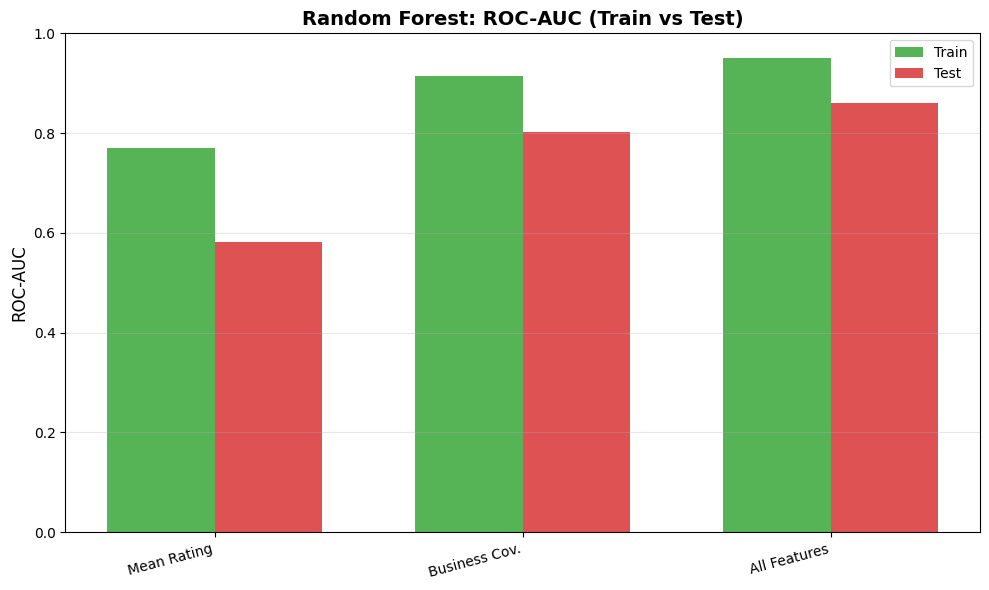


Bestes Random Forest Modell (Test ROC-AUC): RF: All Features
Test ROC-AUC: 0.8607


In [12]:
# Vergleich Random Forest Modelle
rf_results = pd.DataFrame(
    {
        "Model": ["RF: Mean Rating", "RF: Business Covariates", "RF: All Features"],
        "Features": [
            "MEAN (1 Variable)",
            f"{len(X_business.columns)} Variablen",
            f"{len(X_all.columns)} Variablen",
        ],
        "Train ROC-AUC": [
            roc_auc_score(y_train, y_proba_rf_mean_train),
            roc_auc_score(y_train, y_proba_rf_business_train),
            roc_auc_score(y_train, y_proba_rf_all_train),
        ],
        "Test ROC-AUC": [
            roc_auc_score(y_test, y_proba_rf_mean_test),
            roc_auc_score(y_test, y_proba_rf_business_test),
            roc_auc_score(y_test, y_proba_rf_all_test),
        ],
    }
)

print("=" * 80)
print("VERGLEICH RANDOM FOREST MODELLE")
print("=" * 80)
print(rf_results.to_string(index=False))

# Visualisierung
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

x = np.arange(len(rf_results))
width = 0.35

# ROC-AUC
ax.bar(
    x - width / 2,
    rf_results["Train ROC-AUC"],
    width,
    label="Train",
    color="#2ca02c",
    alpha=0.8,
)
ax.bar(
    x + width / 2,
    rf_results["Test ROC-AUC"],
    width,
    label="Test",
    color="#d62728",
    alpha=0.8,
)
ax.set_ylabel("ROC-AUC", fontsize=12)
ax.set_title("Random Forest: ROC-AUC (Train vs Test)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(
    ["Mean Rating", "Business Cov.", "All Features"], rotation=15, ha="right"
)
ax.set_ylim([0, 1])
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Bestes Random Forest Modell
best_rf_idx = rf_results["Test ROC-AUC"].idxmax()
print(
    f"\nBestes Random Forest Modell (Test ROC-AUC): {rf_results.loc[best_rf_idx, 'Model']}"
)
print(f"Test ROC-AUC: {rf_results.loc[best_rf_idx, 'Test ROC-AUC']:.4f}")

# XGBoost Models

---

XGBoost als zusätzliches Benchmark-Modell (nicht im Original-Paper enthalten)


## Model 7: XGBoost mit Mean Rating


In [13]:
from xgboost import XGBClassifier

# Model 7: XGBoost mit Mean Rating
xgb_mean = XGBClassifier(
    random_state=SEED,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
)
xgb_mean.fit(X_mean_train, y_train)

# Predictions
y_proba_xgb_mean_all = xgb_mean.predict_proba(X_mean)[:, 1]
y_proba_xgb_mean_train = xgb_mean.predict_proba(X_mean_train)[:, 1]
y_proba_xgb_mean_test = xgb_mean.predict_proba(X_mean_test)[:, 1]

# Evaluation
print("Parameter:")
print(f"  n_estimators: {xgb_mean.n_estimators}")
print(f"  max_depth: {xgb_mean.max_depth}")
print(f"  learning_rate: {xgb_mean.learning_rate}")

print_model_summary(
    "MODEL 7: XGBoost - Mean Rating",
    y_train,
    y_proba_xgb_mean_train,
    y_test,
    y_proba_xgb_mean_test,
)

# Performance Metrics mit get_model_performance
perf_xgb_mean = get_model_performance(
    y_prob=y_proba_xgb_mean_all,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)
print("\nDetailed Performance Metrics (Calibration + Eval):")
print(perf_xgb_mean)

# Feature Importance
print(f"\nFeature Importance: MEAN = {xgb_mean.feature_importances_[0]:.4f}")

Parameter:
  n_estimators: 100
  max_depth: 3
  learning_rate: 0.1
MODEL 7: XGBoost - Mean Rating

TRAIN Performance:
  ROC-AUC: 0.8065

TEST Performance:
  ROC-AUC: 0.5706

Detailed Performance Metrics (Calibration + Eval):
{'auc': 57.27, 'balanced_accuracy': np.float64(52.28), 'f1': np.float64(33.88), 'specificity': np.float64(48.39), 'sensitivity': np.float64(56.16), 'threshold': np.float32(0.2605)}

Feature Importance: MEAN = 1.0000


## Model 8: XGBoost mit Business Covariates


In [14]:
# Model 8: XGBoost mit Business Covariates
xgb_business = XGBClassifier(
    random_state=SEED,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
)
xgb_business.fit(X_business_train, y_train)

# Predictions
y_proba_xgb_business_all = xgb_business.predict_proba(X_business)[:, 1]
y_proba_xgb_business_train = xgb_business.predict_proba(X_business_train)[:, 1]
y_proba_xgb_business_test = xgb_business.predict_proba(X_business_test)[:, 1]

# Evaluation mit print_model_summary
print_model_summary(
    "MODEL 8: XGBoost - Business Covariates",
    y_train,
    y_proba_xgb_business_train,
    y_test,
    y_proba_xgb_business_test,
)

# Performance Metrics mit get_model_performance
perf_xgb_business = get_model_performance(
    y_prob=y_proba_xgb_business_all,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)
print("\nDetailed Performance Metrics (Calibration + Eval):")
print(perf_xgb_business)

# Top 10 Feature Importances
feature_importance_xgb_business = pd.DataFrame(
    {"feature": X_business.columns, "importance": xgb_business.feature_importances_}
)
feature_importance_xgb_business = feature_importance_xgb_business.sort_values(
    "importance", ascending=False
)

print("\nTop 10 wichtigste Features:")
print(feature_importance_xgb_business.head(10))

MODEL 8: XGBoost - Business Covariates

TRAIN Performance:
  ROC-AUC: 0.9839

TEST Performance:
  ROC-AUC: 0.7851

Detailed Performance Metrics (Calibration + Eval):
{'auc': 78.26, 'balanced_accuracy': np.float64(69.97), 'f1': np.float64(51.89), 'specificity': np.float64(74.19), 'sensitivity': np.float64(65.75), 'threshold': np.float32(0.241)}

Top 10 wichtigste Features:
                     feature  importance
2                      chain    0.284100
5            Number.of.Seats    0.106699
4            Restaurant.Size    0.085772
8                        Age    0.071260
12          category_Mexican    0.059104
16  category_Speciality Food    0.049620
11        category_Fast Food    0.047849
7    Distance.To.City.Centre    0.043958
3                Price.Level    0.043272
1                    Checkin    0.041573


## Model 9: XGBoost mit allen Variablen


In [15]:
# Model 9: XGBoost mit allen Variablen
xgb_all = XGBClassifier(
    random_state=SEED,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
)
xgb_all.fit(X_all_train, y_train)

# Predictions
y_proba_xgb_all_all = xgb_all.predict_proba(X_all)[:, 1]
y_proba_xgb_all_train = xgb_all.predict_proba(X_all_train)[:, 1]
y_proba_xgb_all_test = xgb_all.predict_proba(X_all_test)[:, 1]

# Evaluation mit print_model_summary
print_model_summary(
    "MODEL 9: XGBoost - All Features",
    y_train,
    y_proba_xgb_all_train,
    y_test,
    y_proba_xgb_all_test,
)

# Performance Metrics mit get_model_performance
perf_xgb_all = get_model_performance(
    y_prob=y_proba_xgb_all_all,
    y_exp=y,
    calibration_indices=calibration_indices,
    eval_indices=eval_indices,
)
print("\nDetailed Performance Metrics (Calibration + Eval):")
print(perf_xgb_all)

# Top 10 Feature Importances
feature_importance_xgb_all = pd.DataFrame(
    {"feature": X_all.columns, "importance": xgb_all.feature_importances_}
)
feature_importance_xgb_all = feature_importance_xgb_all.sort_values(
    "importance", ascending=False
)

print("\nTop 10 wichtigste Features:")
print(feature_importance_xgb_all.head(10))

MODEL 9: XGBoost - All Features

TRAIN Performance:
  ROC-AUC: 0.9951

TEST Performance:
  ROC-AUC: 0.8502

Detailed Performance Metrics (Calibration + Eval):
{'auc': 85.59, 'balanced_accuracy': np.float64(76.86), 'f1': np.float64(58.65), 'specificity': np.float64(70.16), 'sensitivity': np.float64(83.56), 'threshold': np.float32(0.1508)}

Top 10 wichtigste Features:
               feature  importance
2                chain    0.152192
17           FIVE_STAR    0.089277
5      Number.of.Seats    0.084392
4      Restaurant.Size    0.064844
16           FOUR_STAR    0.057850
8                  Age    0.052355
21  category_Fast Food    0.038833
22    category_Mexican    0.038245
10                MEAN    0.036043
12               COUNT    0.034651


## Vergleich XGBoost Modelle


VERGLEICH XGBOOST MODELLE
                   Model          Features  Train ROC-AUC  Test ROC-AUC
        XGB: Mean Rating MEAN (1 Variable)       0.806453      0.570639
XGB: Business Covariates      17 Variablen       0.983851      0.785082
       XGB: All Features      27 Variablen       0.995145      0.850224


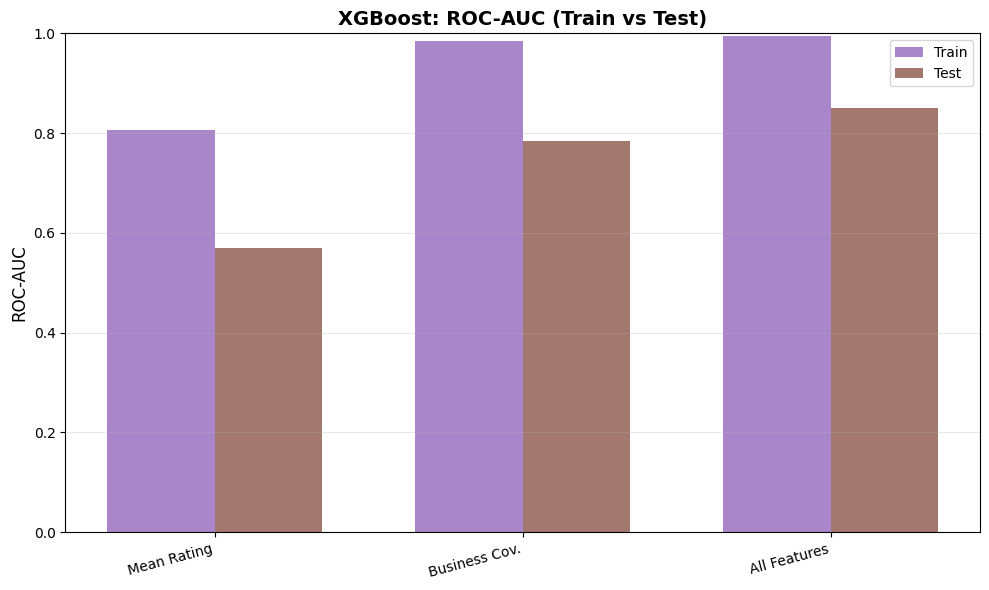


Bestes XGBoost Modell (Test ROC-AUC): XGB: All Features
Test ROC-AUC: 0.8502


In [16]:
# Vergleich XGBoost Modelle
xgb_results = pd.DataFrame(
    {
        "Model": ["XGB: Mean Rating", "XGB: Business Covariates", "XGB: All Features"],
        "Features": [
            "MEAN (1 Variable)",
            f"{len(X_business.columns)} Variablen",
            f"{len(X_all.columns)} Variablen",
        ],
        "Train ROC-AUC": [
            roc_auc_score(y_train, y_proba_xgb_mean_train),
            roc_auc_score(y_train, y_proba_xgb_business_train),
            roc_auc_score(y_train, y_proba_xgb_all_train),
        ],
        "Test ROC-AUC": [
            roc_auc_score(y_test, y_proba_xgb_mean_test),
            roc_auc_score(y_test, y_proba_xgb_business_test),
            roc_auc_score(y_test, y_proba_xgb_all_test),
        ],
    }
)

print("=" * 80)
print("VERGLEICH XGBOOST MODELLE")
print("=" * 80)
print(xgb_results.to_string(index=False))

# Visualisierung
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

x = np.arange(len(xgb_results))
width = 0.35

# ROC-AUC
ax.bar(
    x - width / 2,
    xgb_results["Train ROC-AUC"],
    width,
    label="Train",
    color="#9467bd",
    alpha=0.8,
)
ax.bar(
    x + width / 2,
    xgb_results["Test ROC-AUC"],
    width,
    label="Test",
    color="#8c564b",
    alpha=0.8,
)
ax.set_ylabel("ROC-AUC", fontsize=12)
ax.set_title("XGBoost: ROC-AUC (Train vs Test)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(
    ["Mean Rating", "Business Cov.", "All Features"], rotation=15, ha="right"
)
ax.set_ylim([0, 1])
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Bestes XGBoost Modell
best_xgb_idx = xgb_results["Test ROC-AUC"].idxmax()
print(
    f"\nBestes XGBoost Modell (Test ROC-AUC): {xgb_results.loc[best_xgb_idx, 'Model']}"
)
print(f"Test ROC-AUC: {xgb_results.loc[best_xgb_idx, 'Test ROC-AUC']:.4f}")

# Finaler Gesamtvergleich

---

## Vergleich: Logistic Regression vs Random Forest vs XGBoost


FINALER GESAMTVERGLEICH ALLER MODELLE
         Model Type      Features  Test ROC-AUC  Train ROC-AUC
      Random Forest  All Features      0.860713       0.950645
            XGBoost  All Features      0.850224       0.995145
      Random Forest Business Cov.      0.802458       0.914420
Logistic Regression  All Features      0.796266       0.854130
            XGBoost Business Cov.      0.785082       0.983851
Logistic Regression Business Cov.      0.701144       0.798907
      Random Forest   Mean Rating      0.581617       0.770957
            XGBoost   Mean Rating      0.570639       0.806453
Logistic Regression   Mean Rating      0.523883       0.483745


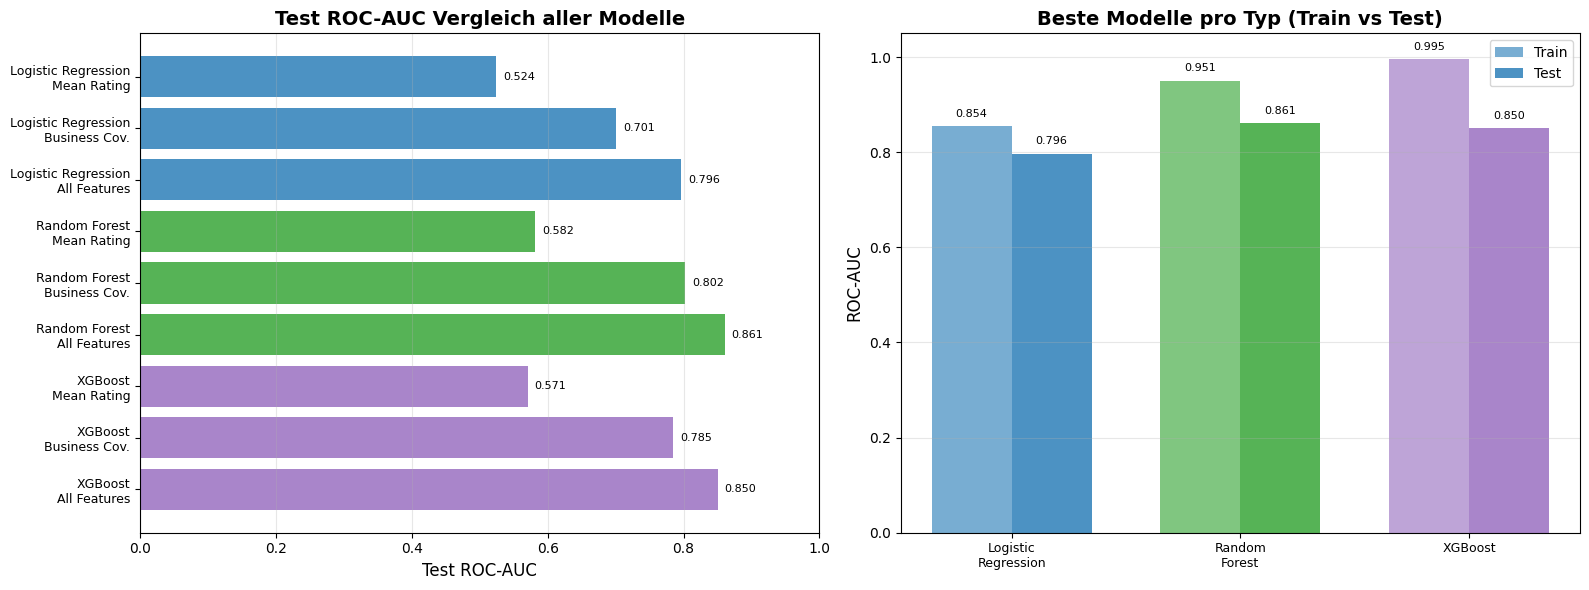


ZUSAMMENFASSUNG

Bestes Modell insgesamt (Test ROC-AUC):
  Random Forest - All Features
  Test ROC-AUC: 0.8607


In [17]:
# Import Helper-Funktionen
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))
from helpers.benchmark_helpers import create_model_comparison_df

# Finaler Gesamtvergleich aller Modelle
model_configs = [
    # Logistic Regression
    {
        "model_type": "Logistic Regression",
        "features": "Mean Rating",
        "y_proba_train": y_proba_mean_train,
        "y_proba_test": y_proba_mean_test,
    },
    {
        "model_type": "Logistic Regression",
        "features": "Business Cov.",
        "y_proba_train": y_proba_business_train,
        "y_proba_test": y_proba_business_test,
    },
    {
        "model_type": "Logistic Regression",
        "features": "All Features",
        "y_proba_train": y_proba_all_train,
        "y_proba_test": y_proba_all_test,
    },
    # Random Forest
    {
        "model_type": "Random Forest",
        "features": "Mean Rating",
        "y_proba_train": y_proba_rf_mean_train,
        "y_proba_test": y_proba_rf_mean_test,
    },
    {
        "model_type": "Random Forest",
        "features": "Business Cov.",
        "y_proba_train": y_proba_rf_business_train,
        "y_proba_test": y_proba_rf_business_test,
    },
    {
        "model_type": "Random Forest",
        "features": "All Features",
        "y_proba_train": y_proba_rf_all_train,
        "y_proba_test": y_proba_rf_all_test,
    },
    # XGBoost
    {
        "model_type": "XGBoost",
        "features": "Mean Rating",
        "y_proba_train": y_proba_xgb_mean_train,
        "y_proba_test": y_proba_xgb_mean_test,
    },
    {
        "model_type": "XGBoost",
        "features": "Business Cov.",
        "y_proba_train": y_proba_xgb_business_train,
        "y_proba_test": y_proba_xgb_business_test,
    },
    {
        "model_type": "XGBoost",
        "features": "All Features",
        "y_proba_train": y_proba_xgb_all_train,
        "y_proba_test": y_proba_xgb_all_test,
    },
]

# Erstelle Vergleichs-DataFrame mit Helper-Funktion
final_comparison = create_model_comparison_df(model_configs, y_train, y_test)

# Sortieren nach Test ROC-AUC
final_comparison_sorted = final_comparison.sort_values("Test ROC-AUC", ascending=False)

print("=" * 100)
print("FINALER GESAMTVERGLEICH ALLER MODELLE")
print("=" * 100)
print(final_comparison_sorted.to_string(index=False))

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Farben für verschiedene Modelltypen
colors_map = {
    "Logistic Regression": "#1f77b4",
    "Random Forest": "#2ca02c",
    "XGBoost": "#9467bd",
}
colors = [colors_map[mt] for mt in final_comparison["Model Type"]]

# 1. Test ROC-AUC Vergleich aller Modelle
model_labels = [
    f"{row['Model Type'][:20]}\n{row['Features'][:15]}"
    for _, row in final_comparison.iterrows()
]
test_roc_scores = final_comparison["Test ROC-AUC"].values

axes[0].barh(range(len(model_labels)), test_roc_scores, color=colors, alpha=0.8)
axes[0].set_yticks(range(len(model_labels)))
axes[0].set_yticklabels(model_labels, fontsize=9)
axes[0].set_xlabel("Test ROC-AUC", fontsize=12)
axes[0].set_title(
    "Test ROC-AUC Vergleich aller Modelle", fontsize=14, fontweight="bold"
)
axes[0].set_xlim([0, 1])
axes[0].grid(axis="x", alpha=0.3)
axes[0].invert_yaxis()

# Werte anzeigen
for i, v in enumerate(test_roc_scores):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)

# 2. Modelltyp-Vergleich (Best von jedem Typ)
best_per_type = final_comparison.loc[
    final_comparison.groupby("Model Type")["Test ROC-AUC"].idxmax()
]
best_labels = best_per_type["Model Type"].values
best_test = best_per_type["Test ROC-AUC"].values
best_train = best_per_type["Train ROC-AUC"].values
best_colors = [colors_map[mt] for mt in best_labels]

x = np.arange(len(best_labels))
width = 0.35

axes[1].bar(
    x - width / 2, best_train, width, label="Train", alpha=0.6, color=best_colors
)
axes[1].bar(x + width / 2, best_test, width, label="Test", alpha=0.8, color=best_colors)
axes[1].set_ylabel("ROC-AUC", fontsize=12)
axes[1].set_title(
    "Beste Modelle pro Typ (Train vs Test)", fontsize=14, fontweight="bold"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [label.replace(" ", "\n") for label in best_labels],
    rotation=0,
    ha="center",
    fontsize=9,
)
axes[1].set_ylim([0, 1.05])
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

# Werte über Balken
for i, (train, test) in enumerate(zip(best_train, best_test)):
    axes[1].text(i - width / 2, train + 0.02, f"{train:.3f}", ha="center", fontsize=8)
    axes[1].text(i + width / 2, test + 0.02, f"{test:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

# Beste Modelle identifizieren
print("\n" + "=" * 100)
print("ZUSAMMENFASSUNG")
print("=" * 100)

best_overall = final_comparison_sorted.iloc[0]
print(f"\nBestes Modell insgesamt (Test ROC-AUC):")
print(f"  {best_overall['Model Type']} - {best_overall['Features']}")
print(f"  Test ROC-AUC: {best_overall['Test ROC-AUC']:.4f}")

# Comprehensive Performance Metrics

---

## Detaillierte Performance-Metriken für alle Modelle

Umfassende Auswertung mit:

- AUC
- Balanced Accuracy
- F1 Score
- Specificity
- Sensitivity
- Optimal Threshold


COMPREHENSIVE MODEL PERFORMANCE METRICS (Calibration + Evaluation Set)
         Model Type      Features   AUC  Balanced Accuracy  F1 Score  Specificity  Sensitivity  Threshold
      Random Forest  All Features 86.16              77.55     60.96        77.02        78.08     0.2484
            XGBoost  All Features 85.59              76.86     58.65        70.16        83.56     0.1508
Logistic Regression  All Features 80.11              71.79     53.54        70.97        72.60     0.2075
      Random Forest Business Cov. 79.37              69.49     50.73        67.74        71.23     0.2553
            XGBoost Business Cov. 78.26              69.97     51.89        74.19        65.75     0.2410
Logistic Regression Business Cov. 70.45              64.08     44.90        52.82        75.34     0.2085
      Random Forest   Mean Rating 60.44              56.34     38.71        38.71        73.97     0.2188
            XGBoost   Mean Rating 57.27              52.28     33.88        48.39

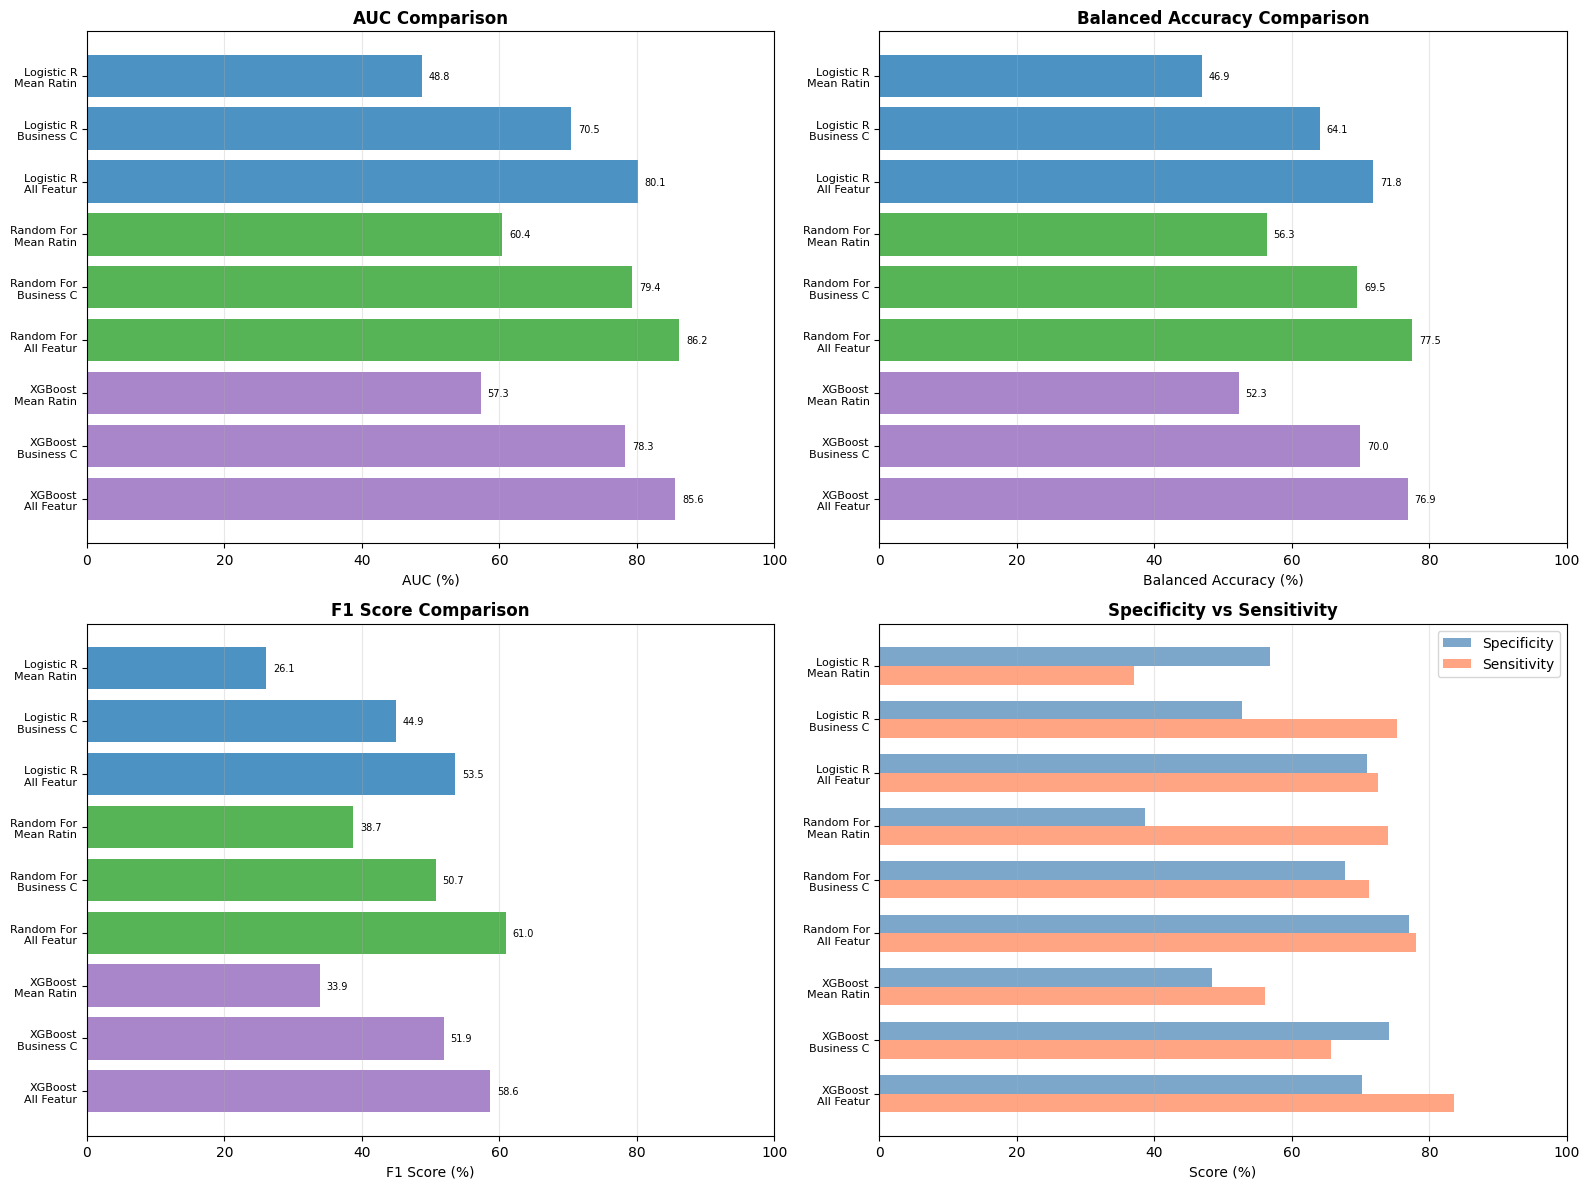


TOP 3 MODELS BY AUC
         Model Type     Features   AUC  Balanced Accuracy  F1 Score  Specificity  Sensitivity  Threshold
      Random Forest All Features 86.16              77.55     60.96        77.02        78.08     0.2484
            XGBoost All Features 85.59              76.86     58.65        70.16        83.56     0.1508
Logistic Regression All Features 80.11              71.79     53.54        70.97        72.60     0.2075


In [18]:
# Sammle alle Performance-Metriken in einem DataFrame
performance_data = []

# Liste aller Modelle mit ihren Performance-Ergebnissen
models_perf = [
    ("Logistic Regression", "Mean Rating", perf_lr_mean),
    ("Logistic Regression", "Business Cov.", perf_lr_business),
    ("Logistic Regression", "All Features", perf_lr_all),
    ("Random Forest", "Mean Rating", perf_rf_mean),
    ("Random Forest", "Business Cov.", perf_rf_business),
    ("Random Forest", "All Features", perf_rf_all),
    ("XGBoost", "Mean Rating", perf_xgb_mean),
    ("XGBoost", "Business Cov.", perf_xgb_business),
    ("XGBoost", "All Features", perf_xgb_all),
]

# DataFrame erstellen
for model_type, features, perf_dict in models_perf:
    performance_data.append(
        {
            "Model Type": model_type,
            "Features": features,
            "AUC": perf_dict["auc"],
            "Balanced Accuracy": perf_dict["balanced_accuracy"],
            "F1 Score": perf_dict["f1"],
            "Specificity": perf_dict["specificity"],
            "Sensitivity": perf_dict["sensitivity"],
            "Threshold": perf_dict["threshold"],
        }
    )

# DataFrame erstellen
comprehensive_performance = pd.DataFrame(performance_data)

# Nach AUC sortieren
comprehensive_performance_sorted = comprehensive_performance.sort_values(
    "AUC", ascending=False
)

print("=" * 120)
print("COMPREHENSIVE MODEL PERFORMANCE METRICS (Calibration + Evaluation Set)")
print("=" * 120)
print(comprehensive_performance_sorted.to_string(index=False))

# Bestes Modell identifizieren
best_model = comprehensive_performance_sorted.iloc[0]
print("\n" + "=" * 120)
print("BEST MODEL OVERALL")
print("=" * 120)
print(f"\nModel: {best_model['Model Type']} - {best_model['Features']}")
print(f"  AUC: {best_model['AUC']}")
print(f"  Balanced Accuracy: {best_model['Balanced Accuracy']}")
print(f"  F1 Score: {best_model['F1 Score']}")
print(f"  Specificity: {best_model['Specificity']}")
print(f"  Sensitivity: {best_model['Sensitivity']}")
print(f"  Optimal Threshold: {best_model['Threshold']}")

# Visualisierung der wichtigsten Metriken
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Farben für verschiedene Modelltypen
colors_map = {
    "Logistic Regression": "#1f77b4",
    "Random Forest": "#2ca02c",
    "XGBoost": "#9467bd",
}

# Modell-Labels für die Plots
model_labels = [
    f"{row['Model Type'][:10]}\n{row['Features'][:10]}"
    for _, row in comprehensive_performance.iterrows()
]
colors = [colors_map[mt] for mt in comprehensive_performance["Model Type"]]

# 1. AUC Vergleich
axes[0, 0].barh(
    range(len(model_labels)),
    comprehensive_performance["AUC"].values,
    color=colors,
    alpha=0.8,
)
axes[0, 0].set_yticks(range(len(model_labels)))
axes[0, 0].set_yticklabels(model_labels, fontsize=8)
axes[0, 0].set_xlabel("AUC (%)", fontsize=10)
axes[0, 0].set_title("AUC Comparison", fontsize=12, fontweight="bold")
axes[0, 0].set_xlim([0, 100])
axes[0, 0].grid(axis="x", alpha=0.3)
axes[0, 0].invert_yaxis()
for i, v in enumerate(comprehensive_performance["AUC"].values):
    axes[0, 0].text(v + 1, i, f"{v:.1f}", va="center", fontsize=7)

# 2. Balanced Accuracy
axes[0, 1].barh(
    range(len(model_labels)),
    comprehensive_performance["Balanced Accuracy"].values,
    color=colors,
    alpha=0.8,
)
axes[0, 1].set_yticks(range(len(model_labels)))
axes[0, 1].set_yticklabels(model_labels, fontsize=8)
axes[0, 1].set_xlabel("Balanced Accuracy (%)", fontsize=10)
axes[0, 1].set_title("Balanced Accuracy Comparison", fontsize=12, fontweight="bold")
axes[0, 1].set_xlim([0, 100])
axes[0, 1].grid(axis="x", alpha=0.3)
axes[0, 1].invert_yaxis()
for i, v in enumerate(comprehensive_performance["Balanced Accuracy"].values):
    axes[0, 1].text(v + 1, i, f"{v:.1f}", va="center", fontsize=7)

# 3. F1 Score
axes[1, 0].barh(
    range(len(model_labels)),
    comprehensive_performance["F1 Score"].values,
    color=colors,
    alpha=0.8,
)
axes[1, 0].set_yticks(range(len(model_labels)))
axes[1, 0].set_yticklabels(model_labels, fontsize=8)
axes[1, 0].set_xlabel("F1 Score (%)", fontsize=10)
axes[1, 0].set_title("F1 Score Comparison", fontsize=12, fontweight="bold")
axes[1, 0].set_xlim([0, 100])
axes[1, 0].grid(axis="x", alpha=0.3)
axes[1, 0].invert_yaxis()
for i, v in enumerate(comprehensive_performance["F1 Score"].values):
    axes[1, 0].text(v + 1, i, f"{v:.1f}", va="center", fontsize=7)

# 4. Specificity vs Sensitivity
x_pos = np.arange(len(model_labels))
width = 0.35
axes[1, 1].barh(
    x_pos - width / 2,
    comprehensive_performance["Specificity"].values,
    width,
    label="Specificity",
    alpha=0.7,
    color="steelblue",
)
axes[1, 1].barh(
    x_pos + width / 2,
    comprehensive_performance["Sensitivity"].values,
    width,
    label="Sensitivity",
    alpha=0.7,
    color="coral",
)
axes[1, 1].set_yticks(x_pos)
axes[1, 1].set_yticklabels(model_labels, fontsize=8)
axes[1, 1].set_xlabel("Score (%)", fontsize=10)
axes[1, 1].set_title("Specificity vs Sensitivity", fontsize=12, fontweight="bold")
axes[1, 1].set_xlim([0, 100])
axes[1, 1].legend()
axes[1, 1].grid(axis="x", alpha=0.3)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

# Top 3 Modelle nach AUC
print("\n" + "=" * 120)
print("TOP 3 MODELS BY AUC")
print("=" * 120)
print(comprehensive_performance_sorted.head(3).to_string(index=False))